In [50]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
protein_data_PR50PT15 = pd.read_csv('final_expression_PR50PT15.csv')

protein_data_PR75PT15 = pd.read_csv('final_expression_PR75PT15.csv')

protein_data_PR80PT15 = pd.read_csv('final_expression_PR80PT15.csv')

protein_data_PR50PT00 = pd.read_csv('final_expression_PR50PT00.csv')

protein_data_PR75PT00 = pd.read_csv('final_expression_PR75PT00.csv')

protein_data_PR80PT00 = pd.read_csv('final_expression_PR80PT00.csv')
print(protein_data_PR50PT15.head(3))

   Genes   Sample 2  Sample 3  Sample 4  Sample 5  Sample 60  Sample 6  \
0  MAPK1  10.202104  9.953741  9.398615  8.750083   8.618377  8.981996   
1  SUGT1   9.787278  7.674279  8.868290  7.480898        NaN  8.244653   
2   RBX1   9.263706  9.463213  8.738964  9.040746   8.210388  8.473520   

    Sample 7  Sample 8  Sample 9  ...  Sample 94  Sample 74  Sample 96  \
0  10.487751  9.487393  9.402815  ...   9.445109   8.092260   7.895789   
1   9.618045  8.504347  7.922264  ...   7.583934        NaN   7.016014   
2   9.384979  9.081190  9.154035  ...   8.876617   8.299928   7.756517   

   Sample 75  Sample 85  Sample 86  Sample 88  Sample 89  Sample 72  Sample 82  
0   9.311878   7.401971   8.935878   7.720153   8.207564        NaN        NaN  
1   8.528882   6.517016   7.648003        NaN        NaN        NaN        NaN  
2   8.827563   7.917300   8.349501        NaN        NaN   7.458433        NaN  

[3 rows x 55 columns]


Go one at a time

In [52]:
protein_data = protein_data_PR50PT00

In [53]:
assert protein_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"

In [54]:
protein_data.shape

(1406, 86)

In [55]:
protein_data.columns

Index(['Genes', 'Sample 1', 'Sample 2', 'Sample 3', 'Sample 4', 'Sample 5',
       'Sample 60', 'Sample 6', 'Sample 7', 'Sample 8', 'Sample 9',
       'Sample 62', 'Sample 10', 'Sample 11', 'Sample 21', 'Sample 12',
       'Sample 13', 'Sample 63', 'Sample 14', 'Sample 15', 'Sample 23',
       'Sample 16', 'Sample 17', 'Sample 64', 'Sample 18', 'Sample 19',
       'Sample 26', 'Sample 20', 'Sample 22', 'Sample 24', 'Sample 25',
       'Sample 30', 'Sample 53', 'Sample 32', 'Sample 33', 'Sample 67',
       'Sample 34', 'Sample 36', 'Sample 68', 'Sample 38', 'Sample 39',
       'Sample 41', 'Sample 69', 'Sample 43', 'Sample 91', 'Sample 45',
       'Sample 70', 'Sample 46', 'Sample 47', 'Sample 92', 'Sample 48',
       'Sample 49', 'Sample 71', 'Sample 50', 'Sample 93', 'Sample 54',
       'Sample 55', 'Sample 57', 'Sample 94', 'Sample 73', 'Sample 74',
       'Sample 80', 'Sample 81', 'Sample 96', 'Sample 75', 'Sample 85',
       'Sample 86', 'Sample 88', 'Sample 89', 'Sample 72', 'Samp

In [ ]:
import pandas as pd

bad_sample_ids = [46, 52, 57, 90]

protein_data_filtered = protein_data.drop(columns=[f'Sample {sample_id}' for sample_id in bad_sample_ids])

print(protein_data_filtered)


        Genes  Sample 1   Sample 2   Sample 3   Sample 4   Sample 5  \
0       MAPK1  7.802514  10.202104   9.953741   9.398615   8.750083   
1       SUGT1       NaN   9.787278   7.674279   8.868290   7.480898   
2        RBX1       NaN   9.263706   9.463213   8.738964   9.040746   
3        PEPD       NaN   8.238970   7.633213   8.197812   7.967809   
4       EEF1G  8.658194  10.967775  12.913032  10.452812  12.098784   
...       ...       ...        ...        ...        ...        ...   
1401     DBNL  6.135507   9.291334  10.415617   8.896279  10.460908   
1402  CAPRIN1       NaN   7.479246   7.536879   7.322532   7.949179   
1403   CSNK2B       NaN   8.895341  10.006287   8.457447   9.860862   
1404     LSM2  7.421572   8.248558  10.250066   7.006929  10.359087   
1405    LMAN1       NaN   7.425526   7.863907   7.215389   7.731895   

      Sample 60   Sample 6   Sample 7   Sample 8  ...  Sample 95  Sample 29  \
0      8.618377   8.981996  10.487751   9.487393  ...        NaN    

Separate features from metadata

In [57]:
gene_symbols = protein_data['Genes']
expression_matrix = protein_data.drop(columns='Genes') 

PLot missingness percentage in patients per data presence filter of protiens 

DP = 0.5, 0.75, 0.8

In [7]:
DP_50 = pd.read_csv('sample_missingness_PR50.csv')

DP_75 = pd.read_csv('sample_missingness_PR75.csv')

DP_80 = pd.read_csv('sample_missingness_PR80.csv')

In [8]:
DP_50.head()

,sample,missingness_percentage
0,Sample 1,23.115220
1,Sample 2,3.769559
2,Sample 3,1.422475
3,Sample 4,5.120910
4,Sample 5,2.204836


/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/53603160.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_samples['sample_number'] = red_samples['sample'].apply(lambda x: int(x.split(' ')[1]))
/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/53603160.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_samples['sample_label'] = red_samples['sample_number'].apply(lambda x: f'Sample.{x}')


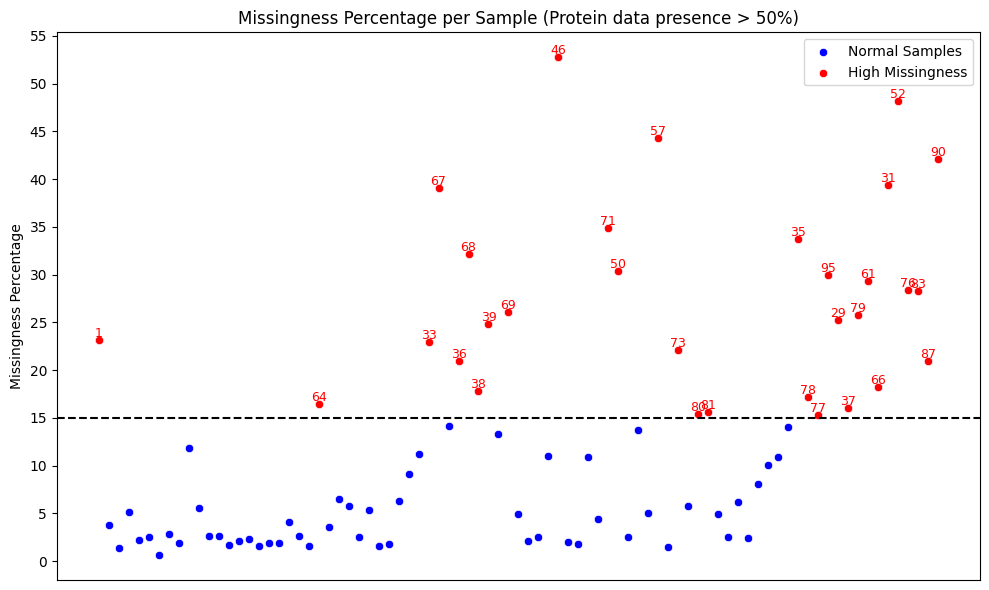

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

missingness_df = DP_50
red_samples = missingness_df[missingness_df['missingness_percentage'] > 15]

sample_info_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels(DP_50).csv')

missingness_df['sample_number'] = missingness_df['sample'].apply(lambda x: int(x.split(' ')[1]))
red_samples['sample_number'] = red_samples['sample'].apply(lambda x: int(x.split(' ')[1]))

red_samples['sample_label'] = red_samples['sample_number'].apply(lambda x: f'Sample.{x}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=missingness_df, x='sample', y='missingness_percentage', color='blue', label='Normal Samples')
sns.scatterplot(data=red_samples, x='sample', y='missingness_percentage', color='red', label='High Missingness')

for i, row in red_samples.iterrows():
    sample_num = row['sample_number']
    plt.text(row['sample'], row['missingness_percentage'], str(sample_num), color='red', fontsize=9, ha='center', va='bottom')

plt.axhline(y=15, color='black', linestyle='--', label='15% Missingness')
plt.xlabel('')
plt.ylabel('Missingness Percentage')
plt.title('Missingness Percentage per Sample (Protein data presence > 50%)')
plt.xticks([])
plt.yticks(range(0, int(missingness_df['missingness_percentage'].max()) + 5, 5))

plt.tight_layout()
plt.show()

filtered_sample_info_df = sample_info_df[sample_info_df['Sample_index'].isin(red_samples['sample_label'])]

filtered_sample_info_df['missingness_percentage'] = filtered_sample_info_df['Sample_index'].apply(
    lambda x: red_samples[red_samples['sample_label'] == x]['missingness_percentage'].values[0]
)

filtered_sample_info_df.to_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels(DP_50).csv', index=False)

/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/1851364652.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_samples['sample_number'] = red_samples['sample'].apply(lambda x: int(x.split(' ')[1]))
/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/1851364652.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_samples['sample_label'] = red_samples['sample_number'].apply(lambda x: f'Sample.{x}')


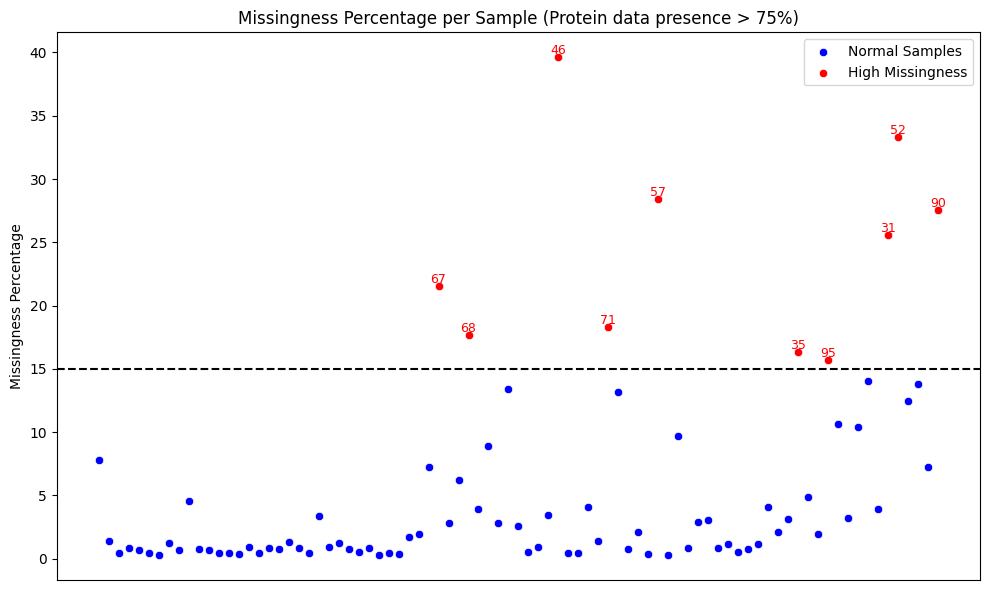

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

missingness_df = DP_75
red_samples = missingness_df[missingness_df['missingness_percentage'] > 15]

sample_info_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels(DP_75).csv')

missingness_df['sample_number'] = missingness_df['sample'].apply(lambda x: int(x.split(' ')[1]))
red_samples['sample_number'] = red_samples['sample'].apply(lambda x: int(x.split(' ')[1]))

red_samples['sample_label'] = red_samples['sample_number'].apply(lambda x: f'Sample.{x}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=missingness_df, x='sample', y='missingness_percentage', color='blue', label='Normal Samples')
sns.scatterplot(data=red_samples, x='sample', y='missingness_percentage', color='red', label='High Missingness')

for i, row in red_samples.iterrows():
    sample_num = row['sample_number']
    plt.text(row['sample'], row['missingness_percentage'], str(sample_num), color='red', fontsize=9, ha='center', va='bottom')

plt.axhline(y=15, color='black', linestyle='--', label='15% Missingness')
plt.xlabel('')
plt.ylabel('Missingness Percentage')
plt.title('Missingness Percentage per Sample (Protein data presence > 75%)')
plt.xticks([])
plt.yticks(range(0, int(missingness_df['missingness_percentage'].max()) + 5, 5))

plt.tight_layout()
plt.show()

filtered_sample_info_df = sample_info_df[sample_info_df['Sample_index'].isin(red_samples['sample_label'])]

filtered_sample_info_df['missingness_percentage'] = filtered_sample_info_df['Sample_index'].apply(
    lambda x: red_samples[red_samples['sample_label'] == x]['missingness_percentage'].values[0]
)

filtered_sample_info_df.to_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels(DP_75).csv', index=False)

/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/4288370991.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_samples['sample_number'] = red_samples['sample'].apply(lambda x: int(x.split(' ')[1]))
/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/4288370991.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_samples['sample_label'] = red_samples['sample_number'].apply(lambda x: f'Sample.{x}')


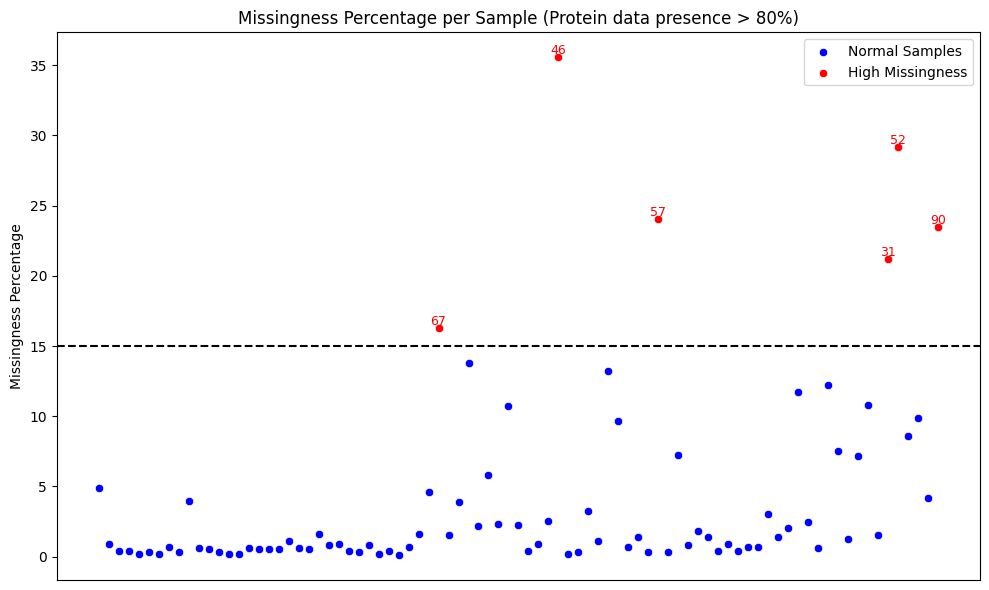

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

missingness_df = DP_80
red_samples = missingness_df[missingness_df['missingness_percentage'] > 15]

sample_info_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels(DP_80).csv')

missingness_df['sample_number'] = missingness_df['sample'].apply(lambda x: int(x.split(' ')[1]))
red_samples['sample_number'] = red_samples['sample'].apply(lambda x: int(x.split(' ')[1]))

red_samples['sample_label'] = red_samples['sample_number'].apply(lambda x: f'Sample.{x}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=missingness_df, x='sample', y='missingness_percentage', color='blue', label='Normal Samples')
sns.scatterplot(data=red_samples, x='sample', y='missingness_percentage', color='red', label='High Missingness')

for i, row in red_samples.iterrows():
    sample_num = row['sample_number']
    plt.text(row['sample'], row['missingness_percentage'], str(sample_num), color='red', fontsize=9, ha='center', va='bottom')

plt.axhline(y=15, color='black', linestyle='--', label='15% Missingness')
plt.xlabel('')
plt.ylabel('Missingness Percentage')
plt.title('Missingness Percentage per Sample (Protein data presence > 80%)')
plt.xticks([])
plt.yticks(range(0, int(missingness_df['missingness_percentage'].max()) + 5, 5))

plt.tight_layout()
plt.show()

filtered_sample_info_df = sample_info_df[sample_info_df['Sample_index'].isin(red_samples['sample_label'])]

filtered_sample_info_df['missingness_percentage'] = filtered_sample_info_df['Sample_index'].apply(
    lambda x: red_samples[red_samples['sample_label'] == x]['missingness_percentage'].values[0]
)

filtered_sample_info_df.to_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels(DP_80).csv', index=False)

Inspect missing data at the expression_matrix level

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer

print("=== Global Missingness ===")
print(f"Total missing values: {expression_matrix.isnull().sum().sum()}")
print(f"Percentage missing: {expression_matrix.isnull().mean().mean()*100:.2f}%")

=== Global Missingness ===
Total missing values: 15882
Percentage missing: 13.29%


Patient-level missingness 


Top 5 patients with most missing data:
Sample 46    0.527738
Sample 52    0.482219
Sample 57    0.443101
Sample 90    0.421053
Sample 31    0.394026
dtype: float64


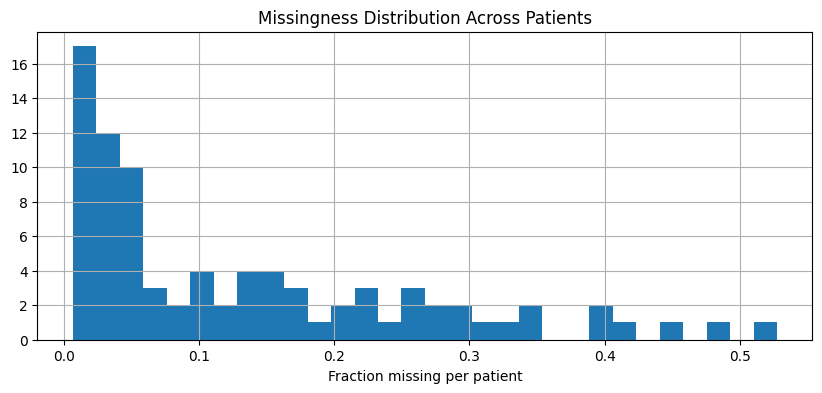

In [17]:
patient_missingness = protein_data.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 5 patients with most missing data:")
print(patient_missingness.sort_values(ascending=False).head())

plt.figure(figsize=(10,4))
patient_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

In [18]:
protein_data.head(10)

,Genes,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 60,Sample 6,Sample 7,Sample 8,...,Sample 37,Sample 79,Sample 61,Sample 66,Sample 31,Sample 52,Sample 76,Sample 83,Sample 87,Sample 90
0,MAPK1,7.802514,10.202104,9.953741,9.398615,8.750083,8.618377,8.981996,10.487751,9.487393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SUGT1,NaN,9.787278,7.674279,8.868290,7.480898,NaN,8.244653,9.618045,8.504347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RBX1,NaN,9.263706,9.463213,8.738964,9.040746,8.210388,8.473520,9.384979,9.081190,...,8.283936,NaN,NaN,8.282974,NaN,NaN,NaN,NaN,NaN,NaN
3,PEPD,NaN,8.238970,7.633213,8.197812,7.967809,7.550712,7.958359,8.622801,7.632371,...,6.532624,5.856336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.132104
4,EEF1G,8.658194,10.967775,12.913032,10.452812,12.098784,10.537974,11.993300,11.524775,12.139093,...,8.728512,8.298091,7.584901,8.766936,6.238077,8.087222,8.059769,7.485998,9.137424,6.618598
5,VTA1,NaN,8.468172,9.322748,8.312569,10.084401,8.747556,8.982010,8.984585,8.922803,...,NaN,NaN,6.496951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,LSM5,6.610382,8.416187,10.032527,7.744039,11.051090,8.795145,9.023262,9.307338,8.707675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.615173,NaN,NaN
7,PFDN1,NaN,9.448796,10.136892,8.829931,10.266574,8.939640,9.386931,10.379843,9.367222,...,8.120749,NaN,NaN,7.816145,NaN,NaN,NaN,7.409969,8.011096,NaN
8,PSMD5,7.072156,8.612993,9.984705,8.199515,10.078999,9.307480,9.699084,9.317669,9.361386,...,7.579031,6.927939,7.555246,8.053018,6.838675,NaN,6.493202,7.054977,7.514430,6.507881
9,RAN,9.607943,10.209488,10.652226,9.618729,10.522399,10.555619,10.637261,10.329228,10.491100,...,9.862163,9.269807,9.726242,9.972201,9.171558,8.820044,9.436711,10.152682,9.691519,8.749798


In [20]:
import pandas as pd
import re

sample_map = pd.read_csv("/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/Proteomics sample labels.csv")

sample_map["sample_id"] = sample_map["Sample_index"].str.extract(r'(\d+)').astype(int)
sample_map = sample_map.set_index("sample_id") 
sample_labels = sample_map["TrueLabel"]  

expression_df = protein_data.copy()

expression_df.columns = [expression_df.columns[0]] + expression_df.columns[1:].str.extract(r'(\d+)')[0].astype(int).tolist()
print(expression_df.shape)
genes_col_df = expression_df.iloc[:, [0]]
expression_df = expression_df.loc[:, expression_df.columns.isin(sample_labels.index)]
print(expression_df.shape)
sample_labels = sample_labels.loc[expression_df.columns]


(1406, 86)
(1406, 85)


In [22]:
print(sample_map.head())

          Sample_index  LabelZ  TrueLabel   Label
sample_id                                        
1             Sample.1    NAAA          0     AAA
2             Sample.2  AAA-DM          1  AAA-DM
3             Sample.3     AAA          0     AAA
4             Sample.4    NAAA          0     AAA
5             Sample.5    NAAA          0     AAA


In [21]:
expression_df.head()
genes_col_df.head()
genes_col_df.to_csv('genes_col_df.csv', index=True, index_label="Index")

In [23]:
import pandas as pd
expr_t = expression_df.T

expr_t["cohort"] = sample_labels

missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.drop(columns="cohort").isna().mean())

missing_by_cohort = missing_by_cohort.T


/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/3430745195.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.drop(columns="cohort").isna().mean())


In [24]:
import pandas as pd 
expression_data = expression_df.copy()

cohorts = expression_data.columns.map(sample_labels)

expression_T = expression_data.T
expression_T['cohort'] = cohorts.values

missingness_per_cohort = (
    expression_T
    .groupby('cohort')
    .apply(lambda df: df.isna().sum().sum() / df.drop(columns='cohort').size * 100)
)

print("Missingness percentage per cohort:")
print(missingness_per_cohort)


Missingness percentage per cohort:
cohort
0    14.322002
1     8.074240
2    17.216690
dtype: float64


/home/vascul/vsayyalasomayajula/tmp/ipykernel_587855/1812452808.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.isna().sum().sum() / df.drop(columns='cohort').size * 100)


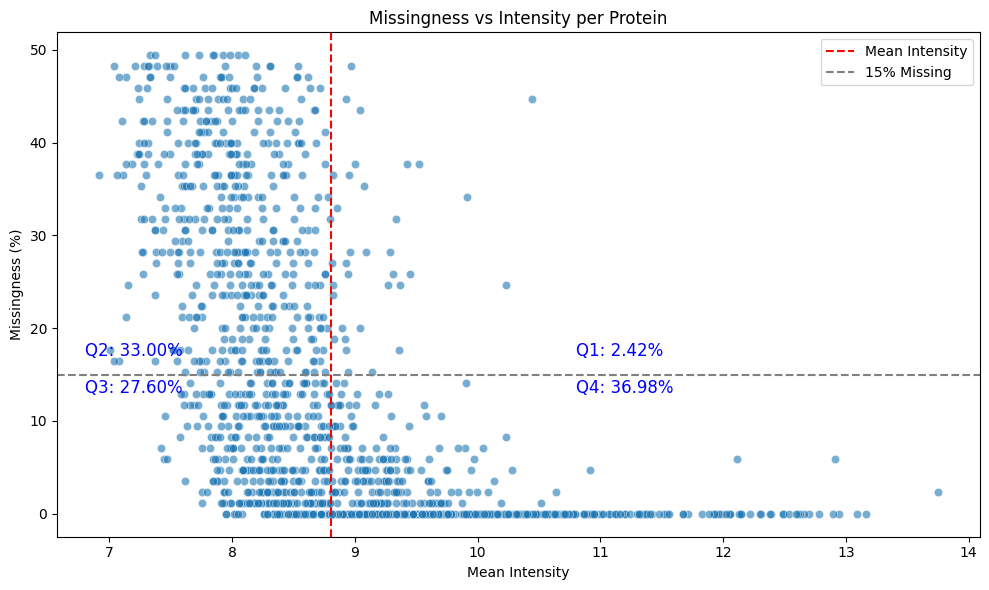

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_intensity = expression_data.mean(axis=1)
missing_percent = expression_data.isna().sum(axis=1) / expression_data.shape[1] * 100

diagnostic_df = pd.DataFrame({
    'mean_intensity': mean_intensity,
    'missing_percent': missing_percent
})

mean_intensity_line = diagnostic_df['mean_intensity'].mean()
missingness_threshold = 15

plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df, x='mean_intensity', y='missing_percent', alpha=0.6)

plt.axvline(mean_intensity_line, color='red', linestyle='--', label='Mean Intensity')
plt.axhline(missingness_threshold, color='gray', linestyle='--', label='15% Missing')

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity per Protein')
plt.legend()

# Compute the quadrants
Q1 = diagnostic_df[(diagnostic_df['mean_intensity'] > mean_intensity_line) & (diagnostic_df['missing_percent'] > missingness_threshold)]
Q2 = diagnostic_df[(diagnostic_df['mean_intensity'] <= mean_intensity_line) & (diagnostic_df['missing_percent'] > missingness_threshold)]
Q3 = diagnostic_df[(diagnostic_df['mean_intensity'] <= mean_intensity_line) & (diagnostic_df['missing_percent'] <= missingness_threshold)]
Q4 = diagnostic_df[(diagnostic_df['mean_intensity'] > mean_intensity_line) & (diagnostic_df['missing_percent'] <= missingness_threshold)]

# Compute percentages for each quadrant
Q1_percent = len(Q1) / len(diagnostic_df) * 100
Q2_percent = len(Q2) / len(diagnostic_df) * 100
Q3_percent = len(Q3) / len(diagnostic_df) * 100
Q4_percent = len(Q4) / len(diagnostic_df) * 100

# Annotate the quadrants
plt.text(mean_intensity_line + 2, missingness_threshold + 2, f'Q1: {Q1_percent:.2f}%', fontsize=12, color='blue')
plt.text(mean_intensity_line - 2, missingness_threshold + 2, f'Q2: {Q2_percent:.2f}%', fontsize=12, color='blue')
plt.text(mean_intensity_line - 2, missingness_threshold - 2, f'Q3: {Q3_percent:.2f}%', fontsize=12, color='blue')
plt.text(mean_intensity_line + 2, missingness_threshold - 2, f'Q4: {Q4_percent:.2f}%', fontsize=12, color='blue')

plt.tight_layout()
plt.show()

In [26]:
print(sample_map.columns)

Index(['Sample_index', 'LabelZ', 'TrueLabel', 'Label'], dtype='object')


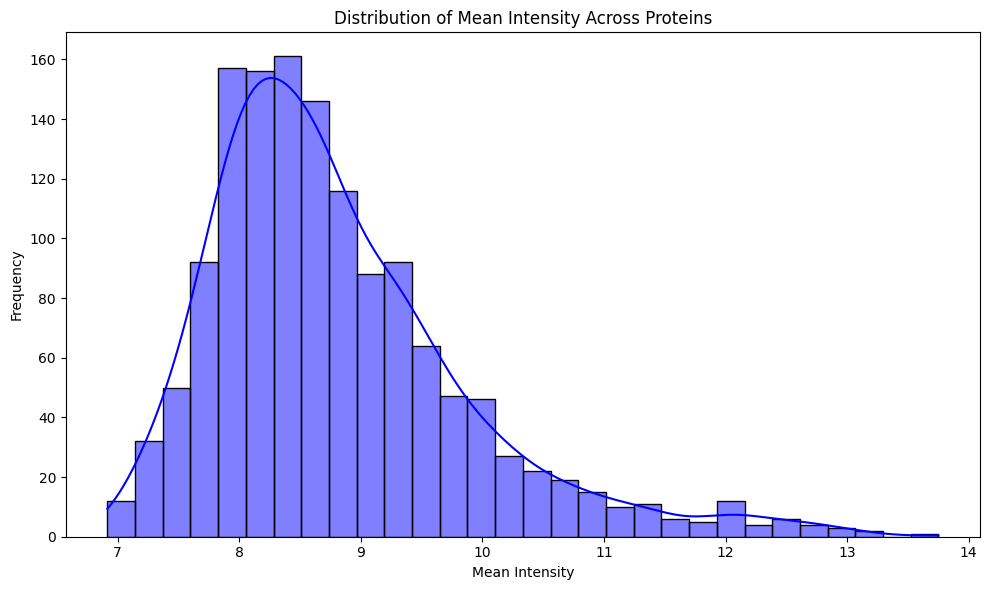

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(mean_intensity, kde=True, color='blue', bins=30)

plt.title('Distribution of Mean Intensity Across Proteins')
plt.xlabel('Mean Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


Per Cohort

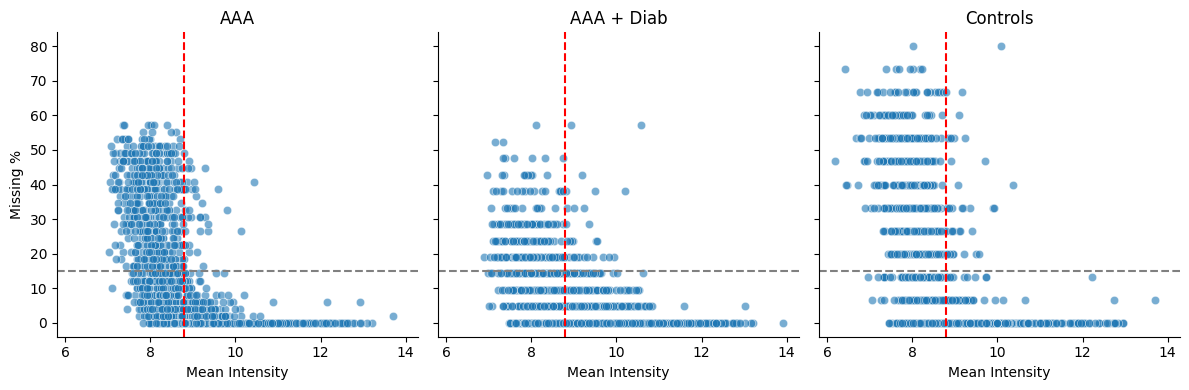

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

expression_T = expression_data.T.copy().reset_index(drop=True)

expression_T['cohort'] = sample_labels.values

long_df = expression_T.melt(id_vars='cohort', var_name='protein', value_name='intensity')

summary_df = (
    long_df
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

cohort_map = {0: 'AAA', 1: 'AAA + Diab', 2: 'Controls'}

g = sns.FacetGrid(
    summary_df,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(15, color='gray', linestyle='--')
    ax.axvline(summary_df['mean_intensity'].mean(), color='red', linestyle='--')

# Set the titles based on the cohort_map dictionary
for i, ax in enumerate(g.axes.flat):
    cohort_value = list(cohort_map.keys())[i]
    ax.set_title(cohort_map[cohort_value])

g.set_axis_labels("Mean Intensity", "Missing %")
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

sample_map['TrueLabel'] = sample_map['TrueLabel'].astype(int)

diagnostic_df['cohort'] = diagnostic_df.index.map(sample_map['TrueLabel'])

if 'cohort' not in diagnostic_df.columns:
    raise KeyError("The 'cohort' column does not exist in diagnostic_df. Please check the mapping process.")

cohort_labels = diagnostic_df['cohort'].unique()

contingency_table = []

for cohort in cohort_labels:
    cohort_data = diagnostic_df[diagnostic_df['cohort'] == cohort]
    missing_data = cohort_data['missing_percent'] > 0
    missing_count = missing_data.sum()
    non_missing_count = len(missing_data) - missing_count

    if missing_count > 0 or non_missing_count > 0:
        contingency_table.append([missing_count, non_missing_count])

contingency_table = np.array(contingency_table)

print("Contingency Table (filtered):")
print(contingency_table)

if contingency_table.shape[0] > 1: 
    g_stat, p_value, _, _ = chi2_contingency(contingency_table)
    print("G-test statistic:", g_stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("The missingness is significantly associated with the cohort (reject null hypothesis).")
    else:
        print("The missingness is not significantly associated with the cohort (fail to reject null hypothesis).")
else:
    print("The contingency table does not have enough data to perform the test.")

Contingency Table (filtered):
[[30 19]
 [15  6]
 [10  5]]
G-test statistic: 0.7008864151721298
p-value: 0.7043758358133018
The missingness is not significantly associated with the cohort (fail to reject null hypothesis).


In [30]:
expression_T.head()

,0,1,2,3,4,5,6,7,8,9,...,1397,1398,1399,1400,1401,1402,1403,1404,1405,cohort
0,7.802514,NaN,NaN,NaN,8.658194,NaN,6.610382,NaN,7.072156,9.607943,...,6.987797,7.062827,10.018413,NaN,6.135507,NaN,NaN,7.421572,NaN,0
1,10.202104,9.787278,9.263706,8.238970,10.967775,8.468172,8.416187,9.448796,8.612993,10.209488,...,NaN,9.677621,9.638915,7.552727,9.291334,7.479246,8.895341,8.248558,7.425526,1
2,9.953741,7.674279,9.463213,7.633213,12.913032,9.322748,10.032527,10.136892,9.984705,10.652226,...,6.735240,10.012455,9.494163,8.400126,10.415617,7.536879,10.006287,10.250066,7.863907,0
3,9.398615,8.868290,8.738964,8.197812,10.452812,8.312569,7.744039,8.829931,8.199515,9.618729,...,NaN,7.837603,9.252454,7.194962,8.896279,7.322532,8.457447,7.006929,7.215389,0
4,8.750083,7.480898,9.040746,7.967809,12.098784,10.084401,11.051090,10.266574,10.078999,10.522399,...,10.285978,9.732048,10.474208,8.050964,10.460908,7.949179,9.860862,10.359087,7.731895,0


In [31]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

expression_T['cohort'] = expression_T['cohort'].astype(int)  

long_df = expression_T.melt(id_vars='cohort', var_name='protein', value_name='intensity')

g_test_results = []


for idx, protein in enumerate(long_df['protein'].unique()):

    protein_data = long_df[long_df['protein'] == protein]
    
    contingency_table = pd.DataFrame(0, index=[0, 1], columns=np.unique(protein_data['cohort'])) 
    
    for cohort in np.unique(protein_data['cohort']):
        cohort_data = protein_data[protein_data['cohort'] == cohort]
        missing_data = cohort_data['intensity'].isna().sum()  # Count missing values
        non_missing_data = len(cohort_data) - missing_data  # Count non-missing values
        
        contingency_table.loc[0, cohort] = non_missing_data  # Non-missing count (0)
        contingency_table.loc[1, cohort] = missing_data  # Missing count (1)
    
    print(f"Contingency Table for Protein {protein} (Index {idx}):")
    print(contingency_table)
    
    if np.any(contingency_table.loc[0] == 0) or np.any(contingency_table.loc[1] == 0):  # If 100% present or 100% missing
        print(f"Skipping G-test for protein {protein} (Index {idx}) due to 100% present or 100% missing values in a cohort.")
        # Add a record for proteins with no missing data
        g_test_results.append({
            'protein_index': idx,
            'protein': protein,
            'g_statistic': None,
            'p_value': None,
            'comment': 'All present or all missing'
        })
        continue

    g_stat, p_value, _, _ = chi2_contingency(contingency_table)
    
    g_test_results.append({
        'protein_index': idx,
        'protein': protein,
        'g_statistic': g_stat,
        'p_value': p_value,
        'comment': 'Test performed'
    })

g_test_df = pd.DataFrame(g_test_results)

g_test_df.to_csv('g_test_results_per_protein_PR50_PT00.csv', index=False)

print(g_test_df)

Contingency Table for Protein 0 (Index 0):
    0   1   2
0  38  18  12
1  11   3   3
Contingency Table for Protein 1 (Index 1):
    0   1  2
0  30  18  6
1  19   3  9
Contingency Table for Protein 2 (Index 2):
    0   1   2
0  30  19  10
1  19   2   5
Contingency Table for Protein 3 (Index 3):
    0   1  2
0  34  20  9
1  15   1  6
Contingency Table for Protein 4 (Index 4):
    0   1   2
0  49  21  15
1   0   0   0
Skipping G-test for protein 4 (Index 4) due to 100% present or 100% missing values in a cohort.
Contingency Table for Protein 5 (Index 5):
    0   1   2
0  37  18  10
1  12   3   5
Contingency Table for Protein 6 (Index 6):
    0   1   2
0  37  20  10
1  12   1   5
Contingency Table for Protein 7 (Index 7):
    0   1   2
0  38  20  13
1  11   1   2
Contingency Table for Protein 8 (Index 8):
    0   1   2
0  46  21  15
1   3   0   0
Skipping G-test for protein 8 (Index 8) due to 100% present or 100% missing values in a cohort.
Contingency Table for Protein 9 (Index 9):
    0 

In [32]:
import pandas as pd
import numpy as np

contingency_tables = []

for protein in long_df['protein'].unique():
    protein_data = long_df[long_df['protein'] == protein]
    
    contingency_table = pd.DataFrame(0, index=[0, 1], columns=np.unique(protein_data['cohort']))  
    
    for cohort in np.unique(protein_data['cohort']):
        cohort_data = protein_data[protein_data['cohort'] == cohort]
        missing_data = cohort_data['intensity'].isna().sum() 
        non_missing_data = len(cohort_data) - missing_data  
        
        contingency_table.loc[0, cohort] = non_missing_data 
        contingency_table.loc[1, cohort] = missing_data 
    
    contingency_tables.append(contingency_table)

multi_index = pd.MultiIndex.from_product([long_df['protein'].unique(), [0, 1], np.unique(long_df['cohort'])],
                                         names=["protein", "missing_status", "cohort"])


contingency_df = pd.DataFrame(np.concatenate([table.values.flatten() for table in contingency_tables]),
                              index=multi_index,
                              columns=["count"])

contingency_df = contingency_df.unstack(level="cohort")

print(contingency_df.head(10))

contingency_df.to_csv('contingency_tables_per_protein_PR50_PT00.csv')

                       count        
cohort                     0   1   2
protein missing_status              
0       0                 38  18  12
        1                 11   3   3
1       0                 30  18   6
        1                 19   3   9
2       0                 30  19  10
        1                 19   2   5
3       0                 34  20   9
        1                 15   1   6
4       0                 49  21  15
        1                  0   0   0


In [33]:

protein_name = 0  

protein_contingency_table = contingency_df.xs(protein_name, level="protein")

print(protein_contingency_table)


               count        
cohort             0   1   2
missing_status              
0                 38  18  12
1                 11   3   3


      protein  significance
0           0             1
1           1             2
2           2             1
3           3             2
4           4             1
...       ...           ...
1401     1401             1
1402     1402             2
1403     1403             1
1404     1404             2
1405     1405             1

[1406 rows x 2 columns]
Proteins with significant missingness association to cohorts:
      protein_index  protein  g_statistic   p_value         comment
1                 1        1     8.157414  0.016929  Test performed
3                 3        3     7.013036  0.030001  Test performed
64               64       64     6.304373  0.042759  Test performed
79               79       79     6.317990  0.042468  Test performed
92               92       92     7.089897  0.028870  Test performed
...             ...      ...          ...       ...             ...
1391           1391     1391     7.546915  0.022972  Test performed
1395           1395     1395     

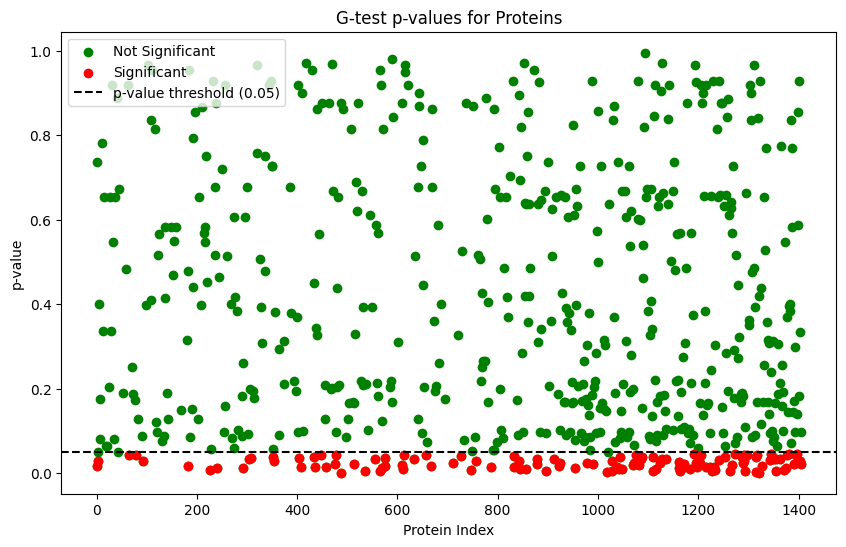

In [34]:

significance_threshold = 0.05

significant_proteins = g_test_df[g_test_df['p_value'] < significance_threshold]

g_test_df['significance'] = g_test_df['p_value'].apply(lambda x: 2 if x < significance_threshold else 1)

g_test_df[['protein', 'significance']].to_csv('proteins_significance_PR50_PT00.csv', index=False)

print(g_test_df[['protein', 'significance']])
print("Proteins with significant missingness association to cohorts:")
print(significant_proteins)

significant_proteins.to_csv('significant_proteins_PR50_PT00.csv', index=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(g_test_df['protein'], g_test_df['p_value'], color='green', label='Not Significant')
plt.scatter(significant_proteins['protein'], significant_proteins['p_value'], color='red', label='Significant')

plt.axhline(y=0.05, color='black', linestyle='--', label="p-value threshold (0.05)")

plt.xlabel('Protein Index')
plt.ylabel('p-value')
plt.title('G-test p-values for Proteins')
plt.legend()
plt.show()


In [35]:
g_test_df['significance'] = g_test_df['p_value'].apply(lambda x: 2 if x < significance_threshold else 1)

g_test_df[['protein', 'significance']].to_csv('proteins_significance_PR50_PT00.csv', index=False)

print(g_test_df[['protein', 'significance']])

      protein  significance
0           0             1
1           1             2
2           2             1
3           3             2
4           4             1
...       ...           ...
1401     1401             1
1402     1402             2
1403     1403             1
1404     1404             2
1405     1405             1

[1406 rows x 2 columns]


In [36]:
genes_col_df = pd.read_csv('genes_col_df.csv', index_col=0)
g_test_df_p = pd.read_csv('proteins_significance_PR50_PT00.csv')

merged_df = pd.merge(genes_col_df, g_test_df_p, left_on='Index', right_on='protein', how='left')

merged_df.to_csv('merged_g_test_df_PR50_PT00.csv', index=False)

print(merged_df.head(20))

      Genes  protein  significance
0     MAPK1        0             1
1     SUGT1        1             2
2      RBX1        2             1
3      PEPD        3             2
4     EEF1G        4             1
5      VTA1        5             1
6      LSM5        6             1
7     PFDN1        7             1
8     PSMD5        8             1
9       RAN        9             1
10    SMIM5       10             1
11   LGALS1       11             1
12  SLC35A4       12             1
13   CAPZA1       13             1
14   PPP1CB       14             1
15   NAP1L4       15             1
16   CAPZA2       16             1
17     CAP1       17             1
18   GAS2L1       18             1
19    CALM1       19             1


In [37]:
non_significant_proteins = g_test_df[g_test_df['significance'] == 1]['protein']
significant_proteins = g_test_df[g_test_df['significance'] == 2]['protein']

In [38]:
g_test_df.head(20)

,protein_index,protein,g_statistic,p_value,comment,significance
0,0,0,0.612245,0.736296,Test performed,1
1,1,1,8.157414,0.016929,Test performed,2
2,2,2,5.988878,0.050065,Test performed,1
3,3,3,7.013036,0.030001,Test performed,2
4,4,4,NaN,NaN,All present or all missing,1
5,5,5,1.823653,0.401790,Test performed,1
6,6,6,5.040106,0.080455,Test performed,1
7,7,7,3.472878,0.176147,Test performed,1
8,8,8,NaN,NaN,All present or all missing,1
9,9,9,NaN,NaN,All present or all missing,1


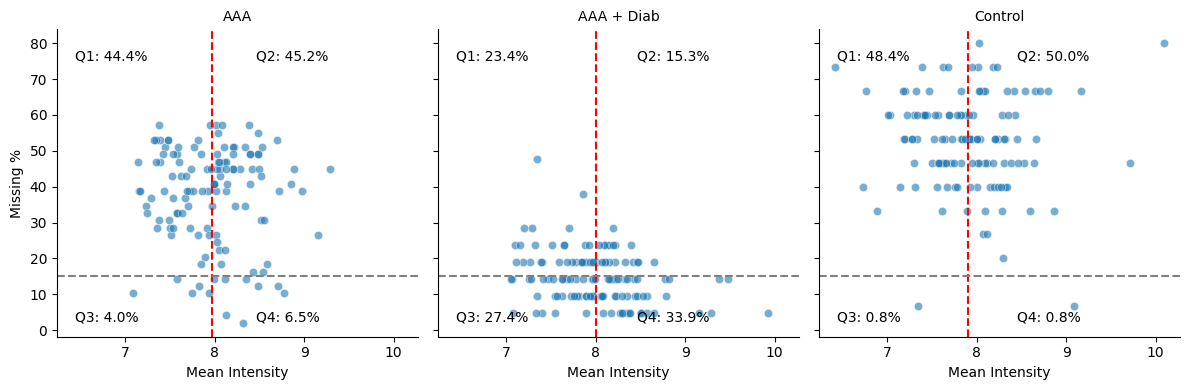

In [39]:
cohort_mapping = {0: "AAA", 1: "AAA + Diab", 2: "Control"}

long_df_sig = long_df[long_df['protein'].isin(significant_proteins)]

summary_df_non_sig = (
    long_df_sig
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

summary_df_non_sig['cohort_label'] = summary_df_non_sig['cohort'].map(cohort_mapping)

cohort_means = summary_df_non_sig.groupby('cohort_label')['mean_intensity'].mean().to_dict()

g = sns.FacetGrid(
    summary_df_non_sig,
    col="cohort_label",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    title = ax.get_title()
    cohort_label = title.split(' = ')[-1]
    mean_val = cohort_means.get(cohort_label, None)
    if mean_val is not None:
        ax.axvline(mean_val, color='red', linestyle='--')
    ax.axhline(15, color='gray', linestyle='--')

    # Filter data for the specific cohort being processed
    cohort_data = summary_df_non_sig[summary_df_non_sig['cohort_label'] == cohort_label]

    # Calculate quadrant points for the cohort
    top_left = cohort_data[(cohort_data['missing_percent'] > 15) & (cohort_data['mean_intensity'] < mean_val)]
    top_right = cohort_data[(cohort_data['missing_percent'] > 15) & (cohort_data['mean_intensity'] >= mean_val)]
    bottom_left = cohort_data[(cohort_data['missing_percent'] <= 15) & (cohort_data['mean_intensity'] < mean_val)]
    bottom_right = cohort_data[(cohort_data['missing_percent'] <= 15) & (cohort_data['mean_intensity'] >= mean_val)]

    total_points = len(cohort_data)
    
    # Calculate percentages for each quadrant
    q1_percentage = len(top_left) / total_points * 100
    q2_percentage = len(top_right) / total_points * 100
    q3_percentage = len(bottom_left) / total_points * 100
    q4_percentage = len(bottom_right) / total_points * 100

    # Annotate the quadrant percentages
    ax.annotate(f'Q1: {q1_percentage:.1f}%', xy=(0.05, 0.9), xycoords='axes fraction', color='black')
    ax.annotate(f'Q2: {q2_percentage:.1f}%', xy=(0.55, 0.9), xycoords='axes fraction', color='black')
    ax.annotate(f'Q3: {q3_percentage:.1f}%', xy=(0.05, 0.05), xycoords='axes fraction', color='black')
    ax.annotate(f'Q4: {q4_percentage:.1f}%', xy=(0.55, 0.05), xycoords='axes fraction', color='black')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()

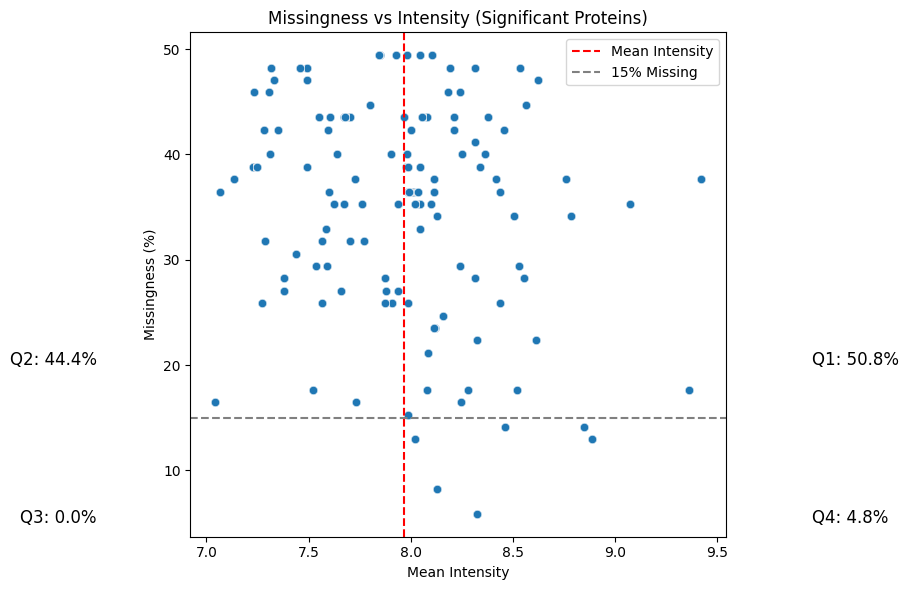

In [40]:
diagnostic_df_non_sig = long_df[long_df['protein'].isin(significant_proteins)]

mean_intensity = diagnostic_df_non_sig.groupby('protein')['intensity'].mean()
missing_percent = diagnostic_df_non_sig.groupby('protein')['intensity'].apply(lambda x: x.isna().mean() * 100)

diagnostic_df_non_sig = diagnostic_df_non_sig.merge(
    mean_intensity.rename('mean_intensity'), on='protein', how='left'
)
diagnostic_df_non_sig = diagnostic_df_non_sig.merge(
    missing_percent.rename('missing_percent'), on='protein', how='left'
)

mean_intensity_val = diagnostic_df_non_sig['mean_intensity'].mean()
missing_threshold = 15

perc_q1 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] > mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] > missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100
perc_q2 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] <= mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] > missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100
perc_q3 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] <= mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] <= missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100
perc_q4 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] > mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] <= missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df_non_sig, x='mean_intensity', y='missing_percent', alpha=0.6)

plt.axvline(mean_intensity_val, color='red', linestyle='--', label='Mean Intensity')
plt.axhline(missing_threshold, color='gray', linestyle='--', label='15% Missing')

plt.text(mean_intensity_val + 2, missing_threshold + 5, f'Q1: {perc_q1:.1f}%', fontsize=12)
plt.text(mean_intensity_val - 1.5, missing_threshold + 5, f'Q2: {perc_q2:.1f}%', fontsize=12, ha='right')
plt.text(mean_intensity_val - 1.5, missing_threshold - 10, f'Q3: {perc_q3:.1f}%', fontsize=12, ha='right')
plt.text(mean_intensity_val + 2, missing_threshold - 10, f'Q4: {perc_q4:.1f}%', fontsize=12)

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity (Significant Proteins)')
plt.legend()
plt.tight_layout()
plt.show()


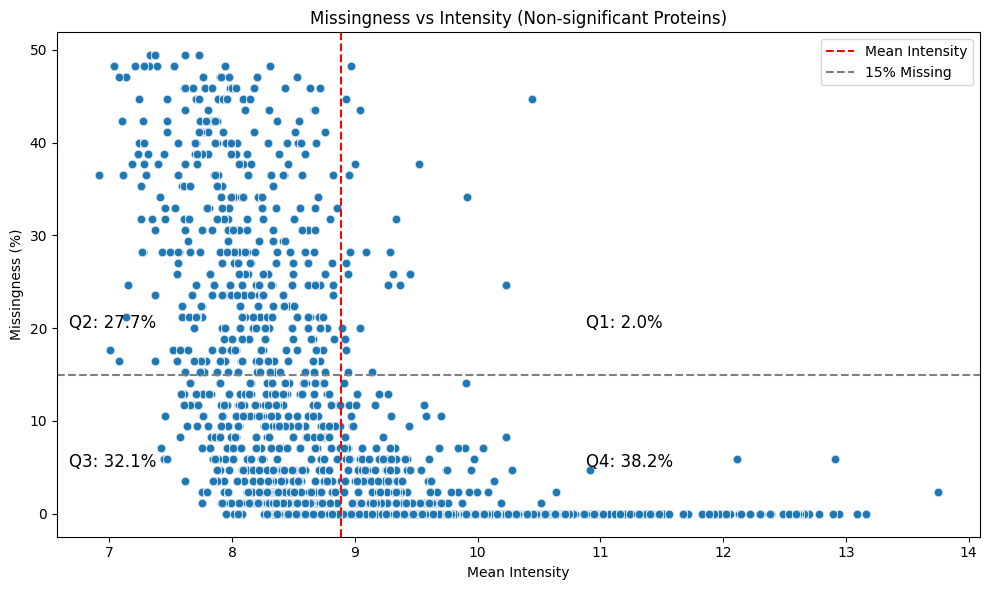

In [41]:
diagnostic_df_non_sig = long_df[long_df['protein'].isin(non_significant_proteins)]

mean_intensity = diagnostic_df_non_sig.groupby('protein')['intensity'].mean()
missing_percent = diagnostic_df_non_sig.groupby('protein')['intensity'].apply(lambda x: x.isna().mean() * 100)

diagnostic_df_non_sig = diagnostic_df_non_sig.merge(
    mean_intensity.rename('mean_intensity'), on='protein', how='left'
)
diagnostic_df_non_sig = diagnostic_df_non_sig.merge(
    missing_percent.rename('missing_percent'), on='protein', how='left'
)

mean_intensity_val = diagnostic_df_non_sig['mean_intensity'].mean()
missing_threshold = 15

perc_q1 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] > mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] > missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100
perc_q2 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] <= mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] > missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100
perc_q3 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] <= mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] <= missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100
perc_q4 = (diagnostic_df_non_sig[(diagnostic_df_non_sig['mean_intensity'] > mean_intensity_val) & 
                                 (diagnostic_df_non_sig['missing_percent'] <= missing_threshold)].shape[0] / diagnostic_df_non_sig.shape[0]) * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df_non_sig, x='mean_intensity', y='missing_percent', alpha=0.6)

plt.axvline(mean_intensity_val, color='red', linestyle='--', label='Mean Intensity')
plt.axhline(missing_threshold, color='gray', linestyle='--', label='15% Missing')

plt.text(mean_intensity_val + 2, missing_threshold + 5, f'Q1: {perc_q1:.1f}%', fontsize=12)
plt.text(mean_intensity_val - 1.5, missing_threshold + 5, f'Q2: {perc_q2:.1f}%', fontsize=12, ha='right')
plt.text(mean_intensity_val - 1.5, missing_threshold - 10, f'Q3: {perc_q3:.1f}%', fontsize=12, ha='right')
plt.text(mean_intensity_val + 2, missing_threshold - 10, f'Q4: {perc_q4:.1f}%', fontsize=12)

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity (Non-significant Proteins)')
plt.legend()
plt.tight_layout()
plt.show()


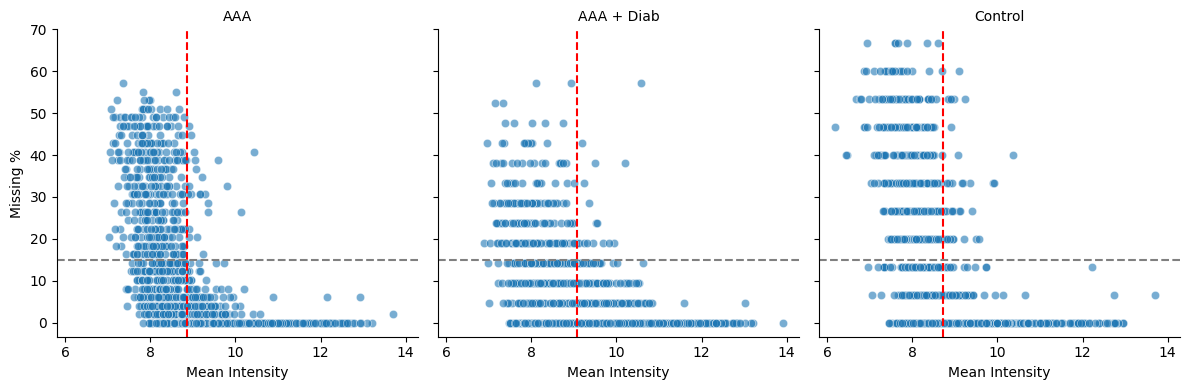

In [42]:
cohort_mapping = {0: "AAA", 1: "AAA + Diab", 2: "Control"}

long_df_sig = long_df[long_df['protein'].isin(non_significant_proteins)]

summary_df_non_sig = (
    long_df_sig
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

summary_df_non_sig['cohort_label'] = summary_df_non_sig['cohort'].map(cohort_mapping)

cohort_means = summary_df_non_sig.groupby('cohort_label')['mean_intensity'].mean().to_dict()

g = sns.FacetGrid(
    summary_df_non_sig,
    col="cohort_label",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    title = ax.get_title()
    cohort_label = title.split(' = ')[-1]
    mean_val = cohort_means.get(cohort_label, None)
    if mean_val is not None:
        ax.axvline(mean_val, color='red', linestyle='--')
    ax.axhline(15, color='gray', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()

In [43]:
diagnostic_df_non_sig.head()

,cohort,protein,intensity,mean_intensity,missing_percent
0,0,0,7.802514,8.772363,20.0
1,1,0,10.202104,8.772363,20.0
2,0,0,9.953741,8.772363,20.0
3,0,0,9.398615,8.772363,20.0
4,0,0,8.750083,8.772363,20.0


Dictionary for proteins matching between plasma and tissue

Omics dictionary

Literature - match with whats reported ...

Annotate based on source and study set up

Olink panel vs untargetted proteins

Screen relatives and blood samples of relatives

Meeting with Regent for proteomics data

Keep all DE proteins from Victor


In [44]:
DEP = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/DEP.csv')
DEP = DEP.drop_duplicates()
print(DEP.shape)

(420, 1)


In [45]:
included_proteins = protein_data_PR50PT00['Genes']
print(len(included_proteins))

1406


In [46]:
included_proteins = protein_data_PR50PT00['Genes']
DEP = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/DEP.csv', header=None)
DEP = DEP.drop_duplicates()

common_proteins = DEP[DEP[0].isin(included_proteins)]
print(len(common_proteins))

396


In [47]:
included_proteins = protein_data_PR50PT00['Genes']
DEP = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/DEP.csv', header=None)
DEP = DEP.drop_duplicates()

excluded_proteins = DEP[~DEP[0].isin(included_proteins)]
print(excluded_proteins)

              0
0       Protein
42      IGKV1-8
58     IGHV3-13
96      ABHD14B
111        WBP2
207        PHB1
215     TSC22D3
245    IGLV1-40
259      ADGRE5
296        NUDC
313  IGHV1-69-2
314        IGHM
342       UBL4A
493    IGLV6-57
523       GSTM3
560    IGHV5-51
572    IGLV8-61
576       ALDOC
582      GIGYF2
603     S100A11
614        MENT
717        DCXR
732     NECTIN2
736    IGLV5-39
746        UTRN


Lets try imputation on protein sets differently

Impute significant proteins per cohort (MAR missingness)

In [ ]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

sample_map["sample_id"] = sample_map["Sample_index"].str.extract(r'(\d+)')[0].astype(int)
sample_map = sample_map.set_index("sample_id")
sample_map['TrueLabel'] = sample_map['TrueLabel'].astype(int)

sample_to_cohort = sample_map['TrueLabel'].to_dict()
cohort_series = pd.Series(expression_df.columns.map(sample_to_cohort), index=expression_df.columns)

protein_meta_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/merged_g_test_df_PR50_PT00.csv')
sig_proteins = protein_meta_df.query('significance == 2')['protein']

expression_df = expression_df.astype(np.float32)
expression_sig = expression_df.loc[expression_df.index.isin(sig_proteins)]

imputed_parts = []
for cohort in cohort_series.unique():
    cohort_samples = cohort_series[cohort_series == cohort].index
    cohort_data = expression_sig[cohort_samples]  


    imputer = IterativeImputer(random_state=42, max_iter=50, tol=1e-3, sample_posterior=True)
    imputed_array = imputer.fit_transform(cohort_data.T)
    imputed_df = pd.DataFrame(imputed_array.T, index=cohort_data.index, columns=cohort_data.columns)

    imputed_parts.append(imputed_df)

imputed_sig_full_MICE = pd.concat(imputed_parts, axis=1).sort_index(axis=1)

expression_df_imputed = expression_df.copy()
expression_df_imputed.loc[expression_sig.index] = imputed_sig_full_MICE

In [ ]:
imputed_sig_full_MICE = imputed_sig_full_MICE
expression_df_imputed_MICE = expression_df_imputed

Evaluate the imputations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

imputed_sig_full = expression_df_imputed_MICE.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

num_parts = 8
chunk_size = (len(proteins) + num_parts - 1) // num_parts

for i in range(num_parts):
    protein_chunk = proteins[i * chunk_size : (i + 1) * chunk_size]
    subset_df = imputed_sig_full.loc[protein_chunk]

    melted_rows = []
    for sample in subset_df.columns:
        cohort = cohort_series[sample]
        for protein in protein_chunk:
            expression_value = subset_df.loc[protein, sample]
            melted_rows.append({
                "Cohort": cohort_map.get(cohort, str(cohort)),
                "Protein": protein_name_map.get(protein, str(protein)),
                "Expression": expression_value
            })
    
    melted_df = pd.DataFrame(melted_rows)

    plt.figure(figsize=(16, 6))
    sns.boxplot(data=melted_df, x="Protein", y="Expression", hue="Cohort")
    plt.title(f"Imputed Expression (Proteins {i * chunk_size + 1} to {min((i + 1) * chunk_size, len(proteins))})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


Side by Side before and after imputation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

color_map = {
    ("AAA", "Expression Before"): "red",
    ("AAA", "Expression After"): "darkred",
    ("AAA + Diab", "Expression Before"): "blue",
    ("AAA + Diab", "Expression After"): "turquoise",
    ("Control", "Expression Before"): "green",
    ("Control", "Expression After"): "darkgreen"
}

order = [
    "AAA - Expression Before", "AAA - Expression After",
    "AAA + Diab - Expression Before", "AAA + Diab - Expression After",
    "Control - Expression Before", "Control - Expression After"
]

imputed_sig_full = expression_df_imputed_MICE.loc[expression_sig.index]
raw_sig_full = expression_sig.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

num_parts = 8
chunk_size = (len(proteins) + num_parts - 1) // num_parts

# Add the missing color combinations to the palette
all_combinations = [
    "AAA - Expression Before", "AAA - Expression After", 
    "AAA + Diab - Expression Before", "AAA + Diab - Expression After", 
    "Control - Expression Before", "Control - Expression After"
]

full_color_map = {comb: color_map.get(tuple(comb.split(" - ")), "gray") for comb in all_combinations}

for i in range(num_parts):
    protein_chunk = proteins[i * chunk_size : (i + 1) * chunk_size]
    raw_df = raw_sig_full.loc[protein_chunk]
    imputed_df = imputed_sig_full.loc[protein_chunk]
    
    melted_rows = []
    for sample in raw_df.columns:
        cohort = cohort_series[sample]
        for protein in protein_chunk:
            expression_value_raw = raw_df.loc[protein, sample]
            expression_value_imputed = imputed_df.loc[protein, sample]
            melted_rows.append({
                "Cohort": cohort_map.get(cohort, str(cohort)),
                "Protein": protein_name_map.get(protein, str(protein)),
                "Expression Before": expression_value_raw,
                "Expression After": expression_value_imputed
            })
    
    melted_df = pd.DataFrame(melted_rows)

    melted_df_melted = melted_df.melt(id_vars=["Cohort", "Protein"], value_vars=["Expression Before", "Expression After"], var_name="Imputation Status", value_name="Expression")

    melted_df_melted['Cohort_Imputation'] = melted_df_melted['Cohort'] + " - " + melted_df_melted['Imputation Status']

    plt.figure(figsize=(16, 6))
    sns.boxplot(x="Protein", y="Expression", hue="Cohort_Imputation", data=melted_df_melted, dodge=True, palette=full_color_map, hue_order = order)

    plt.title(f"Before and After Imputation (Proteins {i * chunk_size + 1} to {min((i + 1) * chunk_size, len(proteins))})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

imputed_sig_full = expression_df_imputed_MICE.loc[expression_sig.index]
raw_sig_full = expression_sig.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

summary_stats = []

for protein in proteins:
    raw_values = raw_sig_full.loc[protein]
    imputed_values = imputed_sig_full.loc[protein]
    
    for cohort_id, cohort_name in cohort_map.items():
        samples = [s for s in raw_values.index if cohort_series[s] == cohort_id]
        
        raw_vals = raw_values[samples]
        imp_vals = imputed_values[samples]
        
        total = len(samples)
        missing = raw_vals.isna().sum()
        missing_pct = (missing / total) * 100 if total > 0 else np.nan
        
        raw_median = raw_vals.median()
        raw_q1 = raw_vals.quantile(0.25)
        raw_q3 = raw_vals.quantile(0.75)
        raw_iqr = raw_q3 - raw_q1

        imp_median = imp_vals.median()
        imp_q1 = imp_vals.quantile(0.25)
        imp_q3 = imp_vals.quantile(0.75)
        imp_iqr = imp_q3 - imp_q1

        summary_stats.append({
            "Protein": protein_name_map.get(protein, str(protein)),
            "Cohort": cohort_name,
            "Missing % (Before)": round(missing_pct, 2),
            "Median (Before)": raw_median,
            "IQR (Before)": raw_iqr,
            "Median (After)": imp_median,
            "IQR (After)": imp_iqr
        })

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv("/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/protein_expression_summary_MICE.csv", index=False)


Trying Random Forrest Imputation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

def rf_impute(df, max_iter=10, random_state=42):
    df = df.copy()
    nan_mask = df.isnull()

    for i in range(max_iter):
        for col in df.columns:
            if nan_mask[col].any():
                not_null_mask = ~nan_mask[col]
                X_train = df.loc[not_null_mask].drop(columns=col)
                y_train = df.loc[not_null_mask, col]
                X_pred = df.loc[nan_mask[col]].drop(columns=col)

                if X_train.shape[0] > 0 and X_pred.shape[0] > 0:
                    model = RandomForestRegressor(n_estimators=100, random_state=random_state)
                    model.fit(X_train, y_train)
                    df.loc[nan_mask[col], col] = model.predict(X_pred)

        if not df.isnull().any().any():
            break

    return df

sample_map["sample_id"] = sample_map["Sample_index"].str.extract(r'(\d+)')[0].astype(int)
sample_map = sample_map.set_index("sample_id")
sample_map['TrueLabel'] = sample_map['TrueLabel'].astype(int)

sample_to_cohort = sample_map['TrueLabel'].to_dict()
cohort_series = pd.Series(expression_df.columns.map(sample_to_cohort), index=expression_df.columns)

protein_meta_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/merged_g_test_df_PR50_PT00.csv')
sig_proteins = protein_meta_df.query('significance == 2')['protein']

expression_df = expression_df.astype(np.float32)
expression_sig = expression_df.loc[expression_df.index.isin(sig_proteins)]

imputed_parts = []
for cohort in cohort_series.unique():
    cohort_samples = cohort_series[cohort_series == cohort].index
    cohort_data = expression_sig[cohort_samples]
    imputed_df = rf_impute(cohort_data.T).T
    imputed_parts.append(imputed_df)

imputed_sig_full_RF = pd.concat(imputed_parts, axis=1).sort_index(axis=1)
expression_df_imputed_RF = expression_df.copy()
expression_df_imputed_RF.loc[expression_sig.index] = imputed_sig_full_RF

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

imputed_sig_full = expression_df_imputed_RF.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

num_parts = 8
chunk_size = (len(proteins) + num_parts - 1) // num_parts

for i in range(num_parts):
    protein_chunk = proteins[i * chunk_size : (i + 1) * chunk_size]
    subset_df = imputed_sig_full.loc[protein_chunk]

    melted_rows = []
    for sample in subset_df.columns:
        cohort = cohort_series[sample]
        for protein in protein_chunk:
            expression_value = subset_df.loc[protein, sample]
            melted_rows.append({
                "Cohort": cohort_map.get(cohort, str(cohort)),
                "Protein": protein_name_map.get(protein, str(protein)),
                "Expression": expression_value
            })
    
    melted_df = pd.DataFrame(melted_rows)

    plt.figure(figsize=(16, 6))
    sns.boxplot(data=melted_df, x="Protein", y="Expression", hue="Cohort")
    plt.title(f"Imputed Expression (Proteins {i * chunk_size + 1} to {min((i + 1) * chunk_size, len(proteins))})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

color_map = {
    ("AAA", "Expression Before"): "red",
    ("AAA", "Expression After"): "darkred",
    ("AAA + Diab", "Expression Before"): "blue",
    ("AAA + Diab", "Expression After"): "turquoise",
    ("Control", "Expression Before"): "green",
    ("Control", "Expression After"): "darkgreen"
}

order = [
    "AAA - Expression Before", "AAA - Expression After",
    "AAA + Diab - Expression Before", "AAA + Diab - Expression After",
    "Control - Expression Before", "Control - Expression After"
]

imputed_sig_full = expression_df_imputed_RF.loc[expression_sig.index]
raw_sig_full = expression_sig.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

num_parts = 8
chunk_size = (len(proteins) + num_parts - 1) // num_parts

all_combinations = [
    "AAA - Expression Before", "AAA - Expression After", 
    "AAA + Diab - Expression Before", "AAA + Diab - Expression After", 
    "Control - Expression Before", "Control - Expression After"
]

full_color_map = {comb: color_map.get(tuple(comb.split(" - ")), "gray") for comb in all_combinations}

for i in range(num_parts):
    protein_chunk = proteins[i * chunk_size : (i + 1) * chunk_size]
    raw_df = raw_sig_full.loc[protein_chunk]
    imputed_df = imputed_sig_full.loc[protein_chunk]
    
    melted_rows = []
    for sample in raw_df.columns:
        cohort = cohort_series[sample]
        for protein in protein_chunk:
            expression_value_raw = raw_df.loc[protein, sample]
            expression_value_imputed = imputed_df.loc[protein, sample]
            melted_rows.append({
                "Cohort": cohort_map.get(cohort, str(cohort)),
                "Protein": protein_name_map.get(protein, str(protein)),
                "Expression Before": expression_value_raw,
                "Expression After": expression_value_imputed
            })
    
    melted_df = pd.DataFrame(melted_rows)

    melted_df_melted = melted_df.melt(id_vars=["Cohort", "Protein"], value_vars=["Expression Before", "Expression After"], var_name="Imputation Status", value_name="Expression")

    melted_df_melted['Cohort_Imputation'] = melted_df_melted['Cohort'] + " - " + melted_df_melted['Imputation Status']

    plt.figure(figsize=(16, 6))
    sns.boxplot(x="Protein", y="Expression", hue="Cohort_Imputation", data=melted_df_melted, dodge=True, palette=full_color_map, hue_order = order)

    plt.title(f"Before and After Imputation (Proteins {i * chunk_size + 1} to {min((i + 1) * chunk_size, len(proteins))})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

imputed_sig_full = expression_df_imputed_RF.loc[expression_sig.index]
raw_sig_full = expression_sig.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

summary_stats = []

for protein in proteins:
    raw_values = raw_sig_full.loc[protein]
    imputed_values = imputed_sig_full.loc[protein]
    
    for cohort_id, cohort_name in cohort_map.items():
        samples = [s for s in raw_values.index if cohort_series[s] == cohort_id]
        
        raw_vals = raw_values[samples]
        imp_vals = imputed_values[samples]
        
        total = len(samples)
        missing = raw_vals.isna().sum()
        missing_pct = (missing / total) * 100 if total > 0 else np.nan
        
        raw_median = raw_vals.median()
        raw_q1 = raw_vals.quantile(0.25)
        raw_q3 = raw_vals.quantile(0.75)
        raw_iqr = raw_q3 - raw_q1

        imp_median = imp_vals.median()
        imp_q1 = imp_vals.quantile(0.25)
        imp_q3 = imp_vals.quantile(0.75)
        imp_iqr = imp_q3 - imp_q1

        summary_stats.append({
            "Protein": protein_name_map.get(protein, str(protein)),
            "Cohort": cohort_name,
            "Missing % (Before)": round(missing_pct, 2),
            "Median (Before)": raw_median,
            "IQR (Before)": raw_iqr,
            "Median (After)": imp_median,
            "IQR (After)": imp_iqr
        })

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv("/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/protein_expression_summary_RF.csv", index=False)


Compare both the imputation techniques

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

protein_names_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/genes_col_df.csv')
protein_name_map = dict(zip(protein_names_df["Index"], protein_names_df["Genes"]))

cohort_map = {
    0: "AAA",
    1: "AAA + Diab",
    2: "Control"
}

color_map = {
    ("AAA", "MICE"): "red",
    ("AAA", "RF"): "darkred",
    ("AAA + Diab", "MICE"): "blue",
    ("AAA + Diab", "RF"): "turquoise",
    ("Control", "MICE"): "green",
    ("Control", "RF"): "darkgreen"
}

order = [
    "AAA - MICE", "AAA - RF",
    "AAA + Diab - MICE", "AAA + Diab - RF",
    "Control - MICE", "Control - RF"
]

imputed_sig_full_RF = expression_df_imputed_RF.loc[expression_sig.index]
imputed_sig_full_MICE = expression_df_imputed_MICE.loc[expression_sig.index]
#raw_sig_full = expression_sig.loc[expression_sig.index]
proteins = list(imputed_sig_full.index)

num_parts = 8
chunk_size = (len(proteins) + num_parts - 1) // num_parts

all_combinations = [
    "AAA - MICE", "AAA - RF", 
    "AAA + Diab - MICE", "AAA + Diab - RF", 
    "Control - MICE", "Control - RF"
]

full_color_map = {comb: color_map.get(tuple(comb.split(" - ")), "gray") for comb in all_combinations}

for i in range(num_parts):
    protein_chunk = proteins[i * chunk_size : (i + 1) * chunk_size]
    raw_df = imputed_sig_full_MICE.loc[protein_chunk]
    imputed_df = imputed_sig_full.loc[protein_chunk]
    
    melted_rows = []
    for sample in raw_df.columns:
        cohort = cohort_series[sample]
        for protein in protein_chunk:
            expression_value_raw = raw_df.loc[protein, sample]
            expression_value_imputed = imputed_df.loc[protein, sample]
            melted_rows.append({
                "Cohort": cohort_map.get(cohort, str(cohort)),
                "Protein": protein_name_map.get(protein, str(protein)),
                "MICE": expression_value_raw,
                "RF": expression_value_imputed
            })
    
    melted_df = pd.DataFrame(melted_rows)

    melted_df_melted = melted_df.melt(id_vars=["Cohort", "Protein"], value_vars=["MICE", "RF"], var_name="Imputation Status", value_name="Expression")

    melted_df_melted['Cohort_Imputation'] = melted_df_melted['Cohort'] + " - " + melted_df_melted['Imputation Status']

    plt.figure(figsize=(16, 6))
    sns.boxplot(x="Protein", y="Expression", hue="Cohort_Imputation", data=melted_df_melted, dodge=True, palette=full_color_map, hue_order = order)

    plt.title(f"Before and After Imputation (Proteins {i * chunk_size + 1} to {min((i + 1) * chunk_size, len(proteins))})")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Check if non-significant proteins follow MAR or MNAR

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

protein_meta_df = pd.read_csv('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/merged_g_test_df_PR50_PT00.csv')

non_significant_proteins = protein_meta_df.query('significance != 2')['protein']

expression_non_significant = expression_df.loc[expression_df.index.isin(non_significant_proteins)]

missing_indicator = expression_non_significant.isnull().any(axis=1).astype(int)

X = expression_non_significant.fillna(0)

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {missing_indicator.shape}')


X = X.values
y = missing_indicator.values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of missingness prediction: {accuracy:.2f}')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

missing_proteins = expression_non_significant.index[expression_non_significant.isnull().any(axis=1)] 
non_missing_proteins = expression_non_significant.index[~expression_non_significant.isnull().any(axis=1)]  
plt.figure(figsize=(10, 6))
sns.kdeplot(expression_non_significant.loc[non_missing_proteins].mean(axis=1), label="Non-Missing Proteins", fill=True)
sns.kdeplot(expression_non_significant.loc[missing_proteins].mean(axis=1), label="Missing Proteins", fill=True)
plt.axvline(expression_non_significant.mean().mean(), color='red', linestyle='--', label="Global Mean Expression")
plt.xlabel("Mean Protein Expression (across samples)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
len(non_missing_proteins)

Now imputing on the rest of the dataset 

In [ ]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

non_sig_proteins = expression_df.index.difference(sig_proteins)
expression_non_sig = expression_df.loc[non_sig_proteins].astype(np.float32)

def batch_mice_impute(df, batch_size=1000):
    imputed_chunks = []
    cols = df.columns
    for i in range(0, len(cols), batch_size):
        print(f"Imputing batch: {i}–{min(i+batch_size, len(cols))}")
        batch = df.iloc[:, i:i+batch_size]
        imputer = IterativeImputer(random_state=42, max_iter=10, sample_posterior=True, n_nearest_features=50, initial_strategy='mean')
        imputed = imputer.fit_transform(batch.T)
        imputed_df = pd.DataFrame(imputed.T, index=batch.index, columns=batch.columns)
        imputed_chunks.append(imputed_df)
    return pd.concat(imputed_chunks, axis=1)

imputed_non_sig_df = batch_mice_impute(expression_non_sig, batch_size=1000)



kNN 

In [ ]:
from sklearn.impute import KNNImputer

def knn_impute(df, n_neighbors=5):
    """kNN imputation (row-wise for proteins)."""
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_data = imputer.fit_transform(df.T)  # Transpose to impute samples as features
    return pd.DataFrame(imputed_data.T, index=df.index, columns=df.columns)

imputed_knn = knn_impute(expression_non_sig)

In [ ]:
import numpy as np
from scipy.stats import norm, truncnorm

def qrilc_impute(df, quantile=0.01):
    """QRILC-like imputation for left-censored (MNAR) data."""
    imputed_df = df.copy()
    for protein in df.index:
        observed = df.loc[protein].dropna()
        if len(observed) == 0:
            continue
        
        detection_limit = np.quantile(observed, quantile)

        mu, sigma = norm.fit(observed)

        missing_mask = df.loc[protein].isna()
        n_missing = missing_mask.sum()
        if n_missing > 0:
            a, b = (-np.inf - mu) / sigma, (detection_limit - mu) / sigma
            imputed_values = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=n_missing)
            imputed_df.loc[protein, missing_mask] = imputed_values
    return imputed_df

imputed_qrilc = qrilc_impute(expression_non_sig)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_imputation_comparison(original_df, imputed_mice, imputed_knn, imputed_qrilc):
    """
    Compare imputation methods by plotting mean protein expression (row-wise).
    
    Args:
        original_df: DataFrame with missing values (rows=proteins, cols=samples).
        imputed_*: DataFrames after imputation (same shape as original_df).
    """
    plt.figure(figsize=(12, 7))
    
    # Calculate row-wise means (proteins)
    original_means = original_df.dropna().mean(axis=1)  # Non-missing proteins only
    mice_means = imputed_mice.mean(axis=1)
    knn_means = imputed_knn.mean(axis=1)
    qrilc_means = imputed_qrilc.mean(axis=1)
    
    # Plot distributions
    sns.kdeplot(original_means, label="Original (Non-missing)", color="black", linestyle="--", linewidth=2)
    sns.kdeplot(mice_means, label="MICE", color="blue", fill=True, alpha=0.3)
    sns.kdeplot(knn_means, label="kNN", color="green", fill=True, alpha=0.3)
    sns.kdeplot(qrilc_means, label="QRILC", color="red", fill=True, alpha=0.3)
    
    # Add global mean reference
    global_mean = original_df.mean().mean()  # Mean of all sample values
    plt.axvline(global_mean, color='gray', linestyle=':', label="Global Mean (All Samples)")
    
    plt.xlabel("Mean Protein Expression (Across Samples)")
    plt.ylabel("Density")
    plt.title("Imputation Method Comparison (Rows = Proteins)")
    plt.legend()
    plt.show()

# Usage
plot_imputation_comparison(
    original_df=expression_non_sig,          # Original data with missing values
    imputed_mice=imputed_non_sig_df,         # MICE-imputed
    imputed_knn=imputed_knn,                 # kNN-imputed
    imputed_qrilc=imputed_qrilc              # QRILC-imputed
)

In [ ]:
print("Shape Check:")
print(f"Original: {expression_non_sig.shape} (rows=proteins, cols=samples)")
print(f"MICE: {imputed_non_sig_df.shape}")
print(f"kNN: {imputed_knn.shape}")
print(f"QRILC: {imputed_qrilc.shape}")

# Check if indices (proteins) match
assert all(expression_non_sig.index == imputed_non_sig_df.index), "MICE indices mismatch!"
assert all(expression_non_sig.index == imputed_knn.index), "kNN indices mismatch!"
assert all(expression_non_sig.index == imputed_qrilc.index), "QRILC indices mismatch!"

In [ ]:
from sklearn.decomposition import PCA

def plot_pca_comparison(*dfs, labels):
    plt.figure(figsize=(15, 5))
    for i, (df, label) in enumerate(zip(dfs, labels), 1):
        pca = PCA(n_components=2)
        scores = pca.fit_transform(df.T)  # Transpose to samples x proteins
        plt.subplot(1, len(dfs), i)
        plt.scatter(scores[:, 0], scores[:, 1], alpha=0.6, label=label)
        plt.xlabel("PC1")
        plt.ylabel("PC2" if i == 1 else "")
        plt.title(label)
    plt.tight_layout()
    plt.show()

# Usage
plot_pca_comparison(
    imputed_non_sig_df, imputed_knn, imputed_qrilc,
    labels=["MICE", "kNN", "QRILC"]
)

In [ ]:
pca = PCA().fit(imputed_qrilc.T)
plt.plot(np.cumsum(pca.explained_variance_ratio_), label="QRILC")
pca = PCA().fit(imputed_non_sig_df.T)
plt.plot(np.cumsum(pca.explained_variance_ratio_), label="MICE")
pca = PCA().fit(imputed_knn.T)
plt.plot(np.cumsum(pca.explained_variance_ratio_), label="kNN")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.legend()

In [ ]:
expression_df_imputed_RF.loc[non_sig_proteins] = imputed_qrilc
expression_df_imputed_RF_QRILC = expression_df_imputed_RF.copy()

In [ ]:
assert all(expression_df_imputed_RF.index == gene_symbols.index)
expression_df_imputed_RF_QRILC.insert(0, 'proteins', gene_symbols)


In [ ]:
expression_df_imputed_RF_QRILC.to_csv("/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/expression_df_imputed_RF_QRILC.csv", index=False)